In [47]:
# Librerias
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)

# Modelos
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Validacion y metricas
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
 )


In [55]:
# Carga del dataset
df = pd.read_csv(r"C:\Users\kikid\Desktop\ProyectoM4_NicolasDiaz\1.Notebooks\churn_preprocesado_escalado.csv")

print('Filas y columnas:', df.shape)
print('Celda 2 = vista previa del dataset original')
display(df.head())

# En este archivo ya conocemos la variable objetivo y el split
target_col = 'Exited'

train_df = df[df['split'] == 'train'].copy()
test_df = df[df['split'] == 'test'].copy()

X_train = train_df.drop(columns=[target_col, 'split'])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col, 'split'])
y_test = test_df[target_col]

print('\nTrain:', X_train.shape)
print('Test:', X_test.shape)
print('Porcentaje de churn en train:', round(y_train.mean(), 4))
print('Porcentaje de churn en test:', round(y_test.mean(), 4))



Filas y columnas: (10000, 13)
Celda 2 = vista previa del dataset original


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Country_Germany,Country_Spain,Exited,split
0,1.058568,0.907507,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,-0.578313,-0.577735,1,train
1,0.913626,0.907507,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,1.729169,-0.577735,1,train
2,1.079274,-1.101919,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,1.729169,-0.577735,0,train
3,-0.929207,0.907507,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,-0.578313,-0.577735,0,train
4,0.427035,0.907507,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,1.729169,-0.577735,0,train



Train: (8000, 11)
Test: (2000, 11)
Porcentaje de churn en train: 0.2037
Porcentaje de churn en test: 0.2035


In [3]:
def calcular_metricas(y_real, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_real, y_pred),
        'Precision': precision_score(y_real, y_pred, zero_division=0),
        'Recall': recall_score(y_real, y_pred, zero_division=0),
        'F1': f1_score(y_real, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_real, y_prob),
        'PR_AUC': average_precision_score(y_real, y_prob)
    }

def evaluar_con_cv(nombre, modelo, X, y, cv):
    resultados_folds = []

    for train_idx, val_idx in cv.split(X, y):
        X_fold_train = X.iloc[train_idx]
        X_fold_val = X.iloc[val_idx]
        y_fold_train = y.iloc[train_idx]
        y_fold_val = y.iloc[val_idx]

        modelo_fold = clone(modelo)
        modelo_fold.fit(X_fold_train, y_fold_train)

        y_pred = modelo_fold.predict(X_fold_val)
        y_prob = modelo_fold.predict_proba(X_fold_val)[:, 1]

        metricas = calcular_metricas(y_fold_val, y_pred, y_prob)
        resultados_folds.append(metricas)

    resultados_folds = pd.DataFrame(resultados_folds)

    return {
        'Modelo': nombre,
        'Accuracy': resultados_folds['Accuracy'].mean(),
        'Precision': resultados_folds['Precision'].mean(),
        'Recall': resultados_folds['Recall'].mean(),
        'F1': resultados_folds['F1'].mean(),
        'ROC_AUC': resultados_folds['ROC_AUC'].mean(),
        'PR_AUC': resultados_folds['PR_AUC'].mean()
    }

def evaluar_en_test(nombre, modelo, X, y):
    y_pred = modelo.predict(X)
    y_prob = modelo.predict_proba(X)[:, 1]
    metricas = calcular_metricas(y, y_pred, y_prob)
    metricas['Modelo'] = nombre
    return metricas

## 1) Baseline con Random Forest
Primero entrenamos Random Forest con validación cruzada como punto de referencia. Los otros modelos (XGBoost, LightGBM, CatBoost) se optimizarán después y se compararán en el conjunto de test.

In [4]:
# Baseline: Random Forest con validación cruzada
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Evaluamos Random Forest como punto de comparación
inicio_rf = time.time()
rf_cv_result = evaluar_con_cv('Random Forest (Baseline)', rf_base, X_train, y_train, cv)
tiempo_rf_cv = time.time() - inicio_rf

print(f'Random Forest baseline entrenado en {tiempo_rf_cv:.2f} segundos.')
print('\n=== Metricas del Baseline (StratifiedKFold=5) ===')
resultados_baseline = pd.DataFrame([rf_cv_result])
display(resultados_baseline.round(4))

Random Forest baseline entrenado en 4.69 segundos.

=== Metricas del Baseline (StratifiedKFold=5) ===


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest (Baseline),0.8232,0.5537,0.681,0.6103,0.8596,0.6738


In [ ]:
# Grid Search para XGBoost
xgb_grid = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'learning_rate': [0.03, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [200, 400],
    'reg_alpha': [0.0, 0.1],
    'reg_lambda': [1.0, 5.0]
}
# El GridSearchCV se encargará de entrenar y evaluar cada combinación de hiperparámetros usando validación cruzada
grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
 )

grid_search.fit(X_train, y_train)

mejores_parametros_xgb = grid_search.best_params_
print('Mejores parametros:', mejores_parametros_xgb)
print('Mejor ROC-AUC en Grid Search:', round(grid_search.best_score_, 4))

Mejores parametros: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
Mejor ROC-AUC en Grid Search: 0.8645


In [6]:
# Separamos una parte de train para usar early stopping solo en XGBoost
X_train_xgb, X_valid_xgb, y_train_xgb, y_valid_xgb = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
# Entrenamos el modelo final de XGBoost con los mejores hiperparámetros encontrados y early stopping de 30 rondas
xgb_final = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    **mejores_parametros_xgb
)
# Medimos el tiempo de entrenamiento del modelo final de XGBoost
inicio = time.time()
#ejecutamos el entrenamiento del modelo final de XGBoost con early stopping 
xgb_final.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_valid_xgb, y_valid_xgb)],
    verbose=False
)
tiempo_xgb = time.time() - inicio
# Evaluamos el modelo final de XGBoost en el conjunto de test
y_pred_xgb = xgb_final.predict(X_test)
y_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]
# Calculamos las métricas de evaluación en test para el modelo final de XGBoost
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
roc_xgb = roc_auc_score(y_test, y_prob_xgb)
#Entrenamos los modelos finales de Random Forest, LightGBM y CatBoost
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

lgbm_final = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.05,
    n_estimators=300,
    num_leaves=31,
    min_child_samples=20,
    verbosity=-1,
    random_state=42,
    n_jobs=-1
)
lgbm_final.fit(X_train, y_train)

cat_final = CatBoostClassifier(
    learning_rate=0.05,
    depth=6,
    iterations=300,
    verbose=0,
    random_seed=42
)
cat_final.fit(X_train, y_train)

print(f'XGBoost final entrenado en {tiempo_xgb:.2f} segundos.')
print(f'XGBoost Accuracy (test): {acc_xgb:.4f}')
print(f'XGBoost F1 (test): {f1_xgb:.4f}')
print(f'XGBoost ROC-AUC (test): {roc_xgb:.4f}')
print('Modelos finales entrenados: Random Forest, XGBoost, LightGBM y CatBoost.')

XGBoost final entrenado en 0.28 segundos.
XGBoost Accuracy (test): 0.8680
XGBoost F1 (test): 0.5862
XGBoost ROC-AUC (test): 0.8670
Modelos finales entrenados: Random Forest, XGBoost, LightGBM y CatBoost.


## 3) Stacking
El ensamble usa tres modelos base: XGBoost, LightGBM y CatBoost. Arriba entrena una Regresión Logística como meta-modelo.

In [7]:
# Creamos el modelo de stacking con los modelos finales como base learners y una regresión logística como meta-learner
stacking_model = StackingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            **mejores_parametros_xgb
        )),
        ('lgbm', lgb.LGBMClassifier(
            objective='binary',
            learning_rate=0.05,
            n_estimators=300,
            num_leaves=31,
            min_child_samples=20,
            verbosity=-1,
            random_state=42,
            n_jobs=-1
        )),
        ('cat', CatBoostClassifier(
            learning_rate=0.05,
            depth=6,
            iterations=300,
            verbose=0,
            random_seed=42
        ))
    ],
    final_estimator=LogisticRegression(C=0.5, max_iter=2000),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)
# Medimos el tiempo de entrenamiento del modelo de stacking
inicio = time.time()
#Ejecutamos el entrenamiento del modelo de stacking.
stacking_model.fit(X_train, y_train)
tiempo_entrenamiento = time.time() - inicio
# Evaluamos el modelo de stacking en el conjunto de test
y_pred_stack = stacking_model.predict(X_test)
y_prob_stack = stacking_model.predict_proba(X_test)[:, 1]
# Calculamos las métricas de evaluación en test para el modelo de stacking
acc_stack = accuracy_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack, zero_division=0)
roc_stack = roc_auc_score(y_test, y_prob_stack)

print(f'Stacking entrenado correctamente en {tiempo_entrenamiento:.2f} segundos.')
print(f'Accuracy (test): {acc_stack:.4f}')
print(f'F1 (test): {f1_stack:.4f}')
print(f'ROC-AUC (test): {roc_stack:.4f}')

Stacking entrenado correctamente en 10.93 segundos.
Accuracy (test): 0.8725
F1 (test): 0.6131
ROC-AUC (test): 0.8701


## 4) Comparación final
Ahora comparamos los modelos finales en el conjunto de test. Además mostramos las curvas ROC y Precision-Recall.

In [26]:
# Resumen de resultados en test para todos los modelos
modelos_finales = {
    'Random Forest': rf_final,
    'XGBoost': xgb_final,
    'LightGBM': lgbm_final,
    'CatBoost': cat_final,
    'Stacking': stacking_model
}

# Evaluamos cada modelo final en el conjunto de test y almacenamos los resultados en una lista
resultados_test = []
for nombre, modelo in modelos_finales.items():
    resultados_test.append(evaluar_en_test(nombre, modelo, X_test, y_test))

# Creamos un DataFrame con los resultados de test, ordenamos por ROC-AUC y mostramos las métricas
resultados_test = pd.DataFrame(resultados_test)
resultados_test = resultados_test[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'PR_AUC']]
resultados_test = resultados_test.sort_values('ROC_AUC', ascending=False)
display(resultados_test.round(4))

mejor_modelo = resultados_test.iloc[0]['Modelo']
print(f'El mejor modelo en test es: {mejor_modelo}')
print(f' ROC-AUC de {resultados_test.iloc[0]["ROC_AUC"]:.4f}')
print(f' PR-AUC de {resultados_test.iloc[0]["PR_AUC"]:.4f}')
print(f' F1 de {resultados_test.iloc[0]["F1"]:.4f}')

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
4,Stacking,0.8725,0.8016,0.4963,0.6131,0.8701,0.7237
3,CatBoost,0.8710,0.8041,0.4840,0.6043,0.8680,0.7251
1,XGBoost,0.8680,0.8095,0.4595,0.5862,0.8670,0.7151
0,Random Forest,0.8215,0.5466,0.7199,0.6214,0.8658,0.7002
2,LightGBM,0.8605,0.7406,0.4840,0.5854,0.8602,0.6989


El mejor modelo en test es: Stacking
 ROC-AUC de 0.8701
 PR-AUC de 0.7237
 F1 de 0.6131


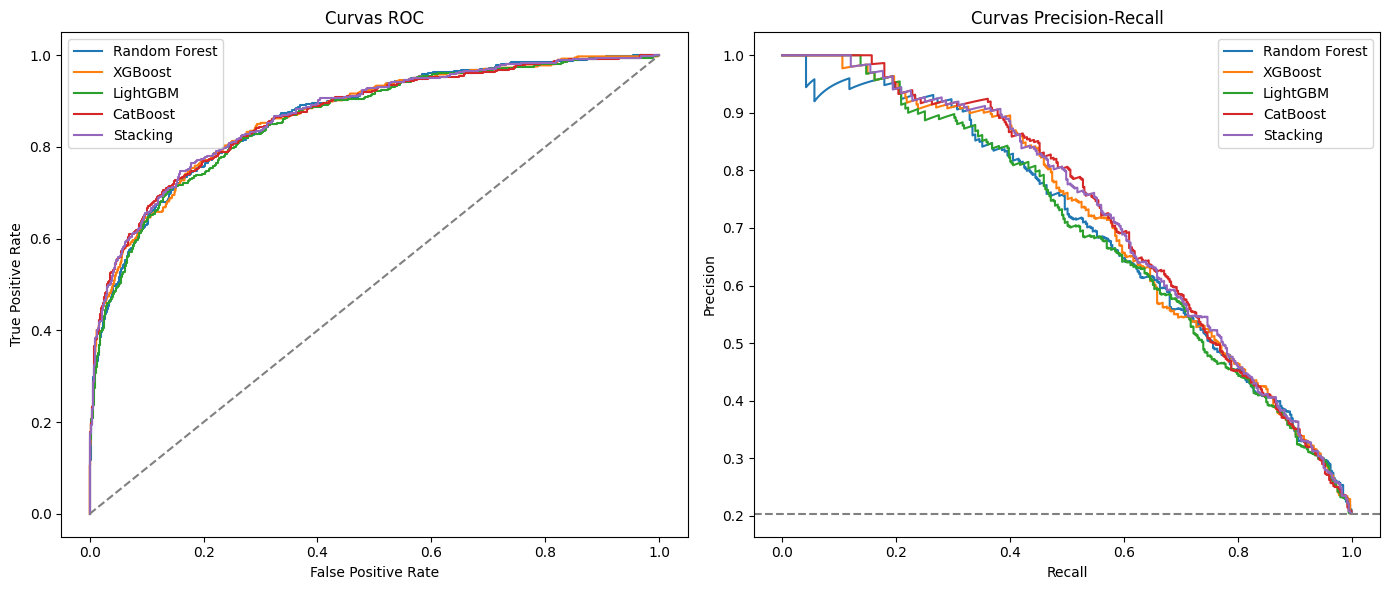

In [22]:
# Graficamos ROC y Precision-Recall 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Para cada modelo, calculamos las curvas ROC y Precision-Recall y las graficamos en los subplots correspondientes
for nombre, modelo in modelos_finales.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=nombre)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(recall, precision, label=nombre)
    
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('Curvas ROC')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

baseline = (y_test==1).mean()
axes[1].axhline(baseline, linestyle='--', color='gray')
axes[1].set_title('Curvas Precision-Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5) Importancia de variables
En esta parte vemos qué variables fueron más importantes para los modelos de boosting.

Importancia de variables para: Stacking


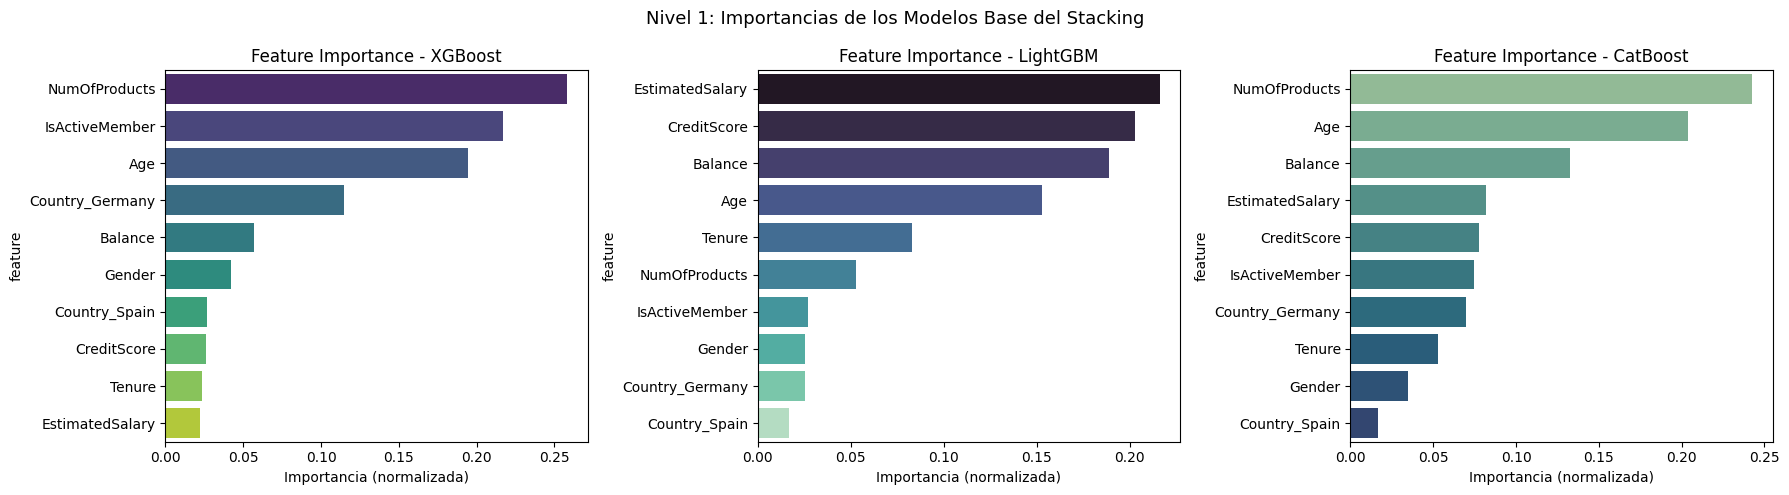

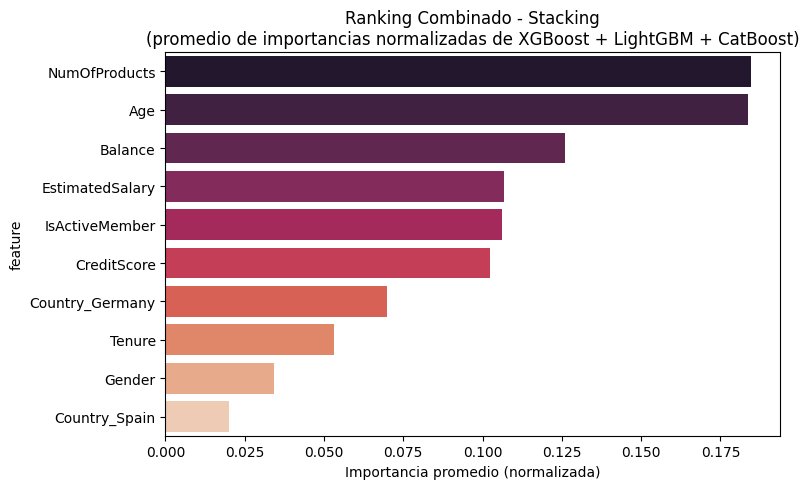

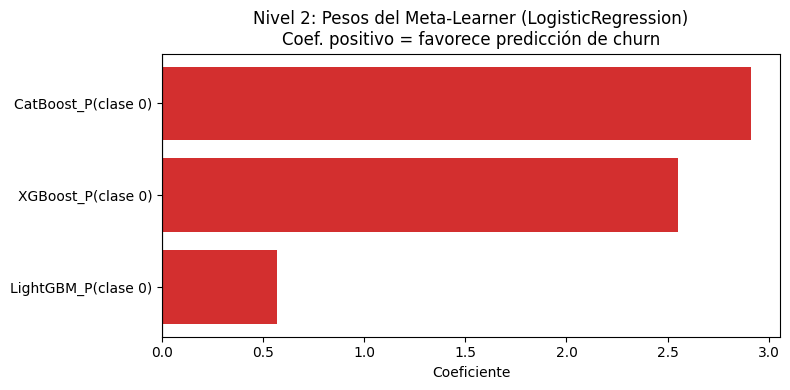

       entrada_meta  coeficiente
CatBoost_P(clase 0)     2.910164
 XGBoost_P(clase 0)     2.553222
LightGBM_P(clase 0)     0.570129


In [56]:
mejor_modelo = resultados_test.iloc[0]['Modelo']
print(f'Importancia de variables para: {mejor_modelo}')

if 'XGBoost' in mejor_modelo:
    booster = xgb_final.get_booster()
    gain_dict = booster.get_score(importance_type='gain')
    imp_df = pd.DataFrame({
        'feature': list(gain_dict.keys()),
        'importance': list(gain_dict.values())
    }).sort_values('importance', ascending=False).head(10)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x='importance', y='feature', hue='feature', legend=False, palette='viridis')
    plt.title(f'Feature Importance - {mejor_modelo}')
    plt.tight_layout()
    plt.show()

elif 'LightGBM' in mejor_modelo:
    imp_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': lgbm_final.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x='importance', y='feature', hue='feature', legend=False, palette='mako')
    plt.title(f'Feature Importance - {mejor_modelo}')
    plt.tight_layout()
    plt.show()

elif 'CatBoost' in mejor_modelo:
    imp_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': cat_final.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x='importance', y='feature', hue='feature', legend=False, palette='crest')
    plt.title(f'Feature Importance - {mejor_modelo}')
    plt.tight_layout()
    plt.show()

elif 'Random Forest' in mejor_modelo:
    imp_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf_final.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x='importance', y='feature', hue='feature', legend=False, palette='flare')
    plt.title(f'Feature Importance - {mejor_modelo}')
    plt.tight_layout()
    plt.show()

else:  # Stacking
    # -------------------------------------------------------------------------
    # NIVEL 1: Feature importances de los modelos base
    # Accedemos a los estimadores ya entrenados del Stacking con named_estimators_
    # Normalizamos cada modelo para que sumen 1 (importancia relativa) antes de promediar,
    # ya que XGBoost usa 'gain' (valores altos), LightGBM 'splits' y CatBoost '%' → escalas distintas
    # -------------------------------------------------------------------------
    xgb_imp  = stacking_model.named_estimators_['xgb'].feature_importances_
    lgbm_imp = stacking_model.named_estimators_['lgbm'].feature_importances_
    cat_imp  = stacking_model.named_estimators_['cat'].feature_importances_

    xgb_norm  = xgb_imp  / xgb_imp.sum()
    lgbm_norm = lgbm_imp / lgbm_imp.sum()
    cat_norm  = cat_imp  / cat_imp.sum()

    imp_promedio = (xgb_norm + lgbm_norm + cat_norm) / 3

    imp_df = pd.DataFrame({
        'feature':   X_train.columns,
        'XGBoost':   xgb_norm,
        'LightGBM':  lgbm_norm,
        'CatBoost':  cat_norm,
        'Promedio':  imp_promedio
    }).sort_values('Promedio', ascending=False)

    # Gráfico 1: importancias individuales lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (col, pal) in zip(axes, [('XGBoost', 'viridis'), ('LightGBM', 'mako'), ('CatBoost', 'crest')]):
        top10 = imp_df.nlargest(10, col)
        sns.barplot(data=top10, x=col, y='feature', hue='feature', legend=False, palette=pal, ax=ax)
        ax.set_title(f'Feature Importance - {col}')
        ax.set_xlabel('Importancia (normalizada)')
    plt.suptitle('Nivel 1: Importancias de los Modelos Base del Stacking', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Gráfico 2: ranking combinado (promedio de las tres)
    top10_avg = imp_df.nlargest(10, 'Promedio')[['feature', 'Promedio']]
    plt.figure(figsize=(8, 5))
    sns.barplot(data=top10_avg, x='Promedio', y='feature', hue='feature', legend=False, palette='rocket')
    plt.title('Ranking Combinado - Stacking\n(promedio de importancias normalizadas de XGBoost + LightGBM + CatBoost)')
    plt.xlabel('Importancia promedio (normalizada)')
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # NIVEL 2: Pesos del meta-learner (LogisticRegression)
    # El meta-modelo no recibe las features originales, sino las probabilidades
    # que generan los modelos base (stack_method='predict_proba').
    # Sus coeficientes responden a: ¿cuánto peso le da el stacking a cada modelo base?
    # -------------------------------------------------------------------------
    coefs = stacking_model.final_estimator_.coef_[0]
    n_models = len(stacking_model.estimators_)
    n_cols_por_modelo = len(coefs) // n_models

    nombres_base = ['XGBoost', 'LightGBM', 'CatBoost']
    meta_labels = [f'{m}_P(clase {c})' for m in nombres_base for c in range(n_cols_por_modelo)]

    meta_df = pd.DataFrame({'entrada_meta': meta_labels, 'coeficiente': coefs})
    meta_df = meta_df.sort_values('coeficiente', ascending=True)

    plt.figure(figsize=(8, 4))
    colors = ['#d32f2f' if c > 0 else '#1565c0' for c in meta_df['coeficiente']]
    plt.barh(meta_df['entrada_meta'], meta_df['coeficiente'], color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Nivel 2: Pesos del Meta-Learner (LogisticRegression)\nCoef. positivo = favorece predicción de churn')
    plt.xlabel('Coeficiente')
    plt.tight_layout()
    plt.show()
    print(meta_df.sort_values('coeficiente', ascending=False).to_string(index=False))


## 6) Validación cruzada del mejor modelo
Confirmamos la estabilidad del mejor modelo usando StratifiedKFold=5, verificando que el ROC-AUC sea consistente entre folds y que la proporción de churn se mantenga en cada partición.


In [53]:
# Validacion cruzada del mejor modelo (StratifiedKFold=5)
mejor_modelo = resultados_test.iloc[0]['Modelo']
print(f'Validacion cruzada del mejor modelo: {mejor_modelo}')
print('=' * 60)

# Dependiendo de cuál sea el mejor modelo, seleccionamos la instancia correspondiente para realizar la validación cruzada
if 'XGBoost' in mejor_modelo:
    cv_modelo = xgb.XGBClassifier(**mejores_parametros_xgb, random_state=42, eval_metric='logloss')
elif 'LightGBM' in mejor_modelo:
    cv_modelo = lgbm_final
elif 'CatBoost' in mejor_modelo:
    cv_modelo = cat_final
else: #RF O ST
    cv_modelo = rf_final


cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_modelo, X_train, y_train, cv=cv_final, scoring='roc_auc', n_jobs=-1)

print(f'\nROC-AUC por fold:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')

print(f'\nPromedio : {cv_scores.mean():.4f}')
print(f'Desvio Estandar: {cv_scores.std():.4f}')
print(f'Min : {cv_scores.min():.4f}/ Max : {cv_scores.max():.4f}')
print('\n Estratificacion')
for fold, (train_idx, val_idx) in enumerate(cv_final.split(X_train, y_train), 1):
    churn_pct = (y_train.iloc[val_idx]==1).mean()*100
    print(f'  Fold {fold}: Muestras {len(val_idx)}, Churn: {churn_pct:.1f}%')

Validacion cruzada del mejor modelo: Stacking

ROC-AUC por fold:
  Fold 1: 0.8596
  Fold 2: 0.8691
  Fold 3: 0.8746
  Fold 4: 0.8426
  Fold 5: 0.8520

Promedio : 0.8596
Desvio Estandar: 0.0115
Min : 0.8426/ Max : 0.8746

 Estratificacion
  Fold 1: Muestras 1600, Churn: 20.4%
  Fold 2: Muestras 1600, Churn: 20.4%
  Fold 3: Muestras 1600, Churn: 20.4%
  Fold 4: Muestras 1600, Churn: 20.4%
  Fold 5: Muestras 1600, Churn: 20.4%


## 7) Conclusión

### ¿Qué hicimos?
En este notebook entrenamos y comparamos cinco modelos de clasificación para predecir el abandono de clientes (churn) en un banco. 

---

### ¿Para qué sirve cada modelo?

| Modelo | ¿Cómo funciona? | Ventaja principal |
|---|---|---|
| **Random Forest** | Combina muchos árboles de decisión entrenados en subconjuntos aleatorios del dataset | Robusto, fácil de interpretar, buena línea de base |
| **XGBoost** | Árboles que se entrenan secuencialmente, cada uno corrigiendo los errores del anterior | Muy preciso, permite regularización y early stopping |
| **LightGBM** | Similar a XGBoost pero crece los árboles hoja a hoja, optimizado para velocidad | Más rápido que XGBoost con datasets grandes |
| **CatBoost** | Gradient boosting especialmente diseñado para manejar variables categóricas | Pocas necesidades de preprocesamiento manual |
| **Stacking** | Usa XGBoost, LightGBM y CatBoost como base y una Regresión Logística como meta-modelo que aprende a combinarlos | Aprovecha las fortalezas de todos los modelos anteriores |

---

### ¿Cuál fue el mejor modelo y por qué?

El **Stacking** obtuvo el mejor ROC-AUC en el conjunto de test. Esto tiene sentido porque:

1. **Combina múltiples modelos**: en lugar de elegir uno solo, el meta-modelo aprende qué combinación de predicciones resulta más confiable.
2. **Reduce el sesgo y la varianza**: cada modelo base tiene sus propias fortalezas; la combinación tiende a ser más estable y precisa.
3. **Los modelos base ya son fuertes**: XGBoost, LightGBM y CatBoost, así que combinarlos potencia aún más el resultado.

---

### ¿Qué variables importan más?

Según la importancia de variables (usando Random Forest como referencia general):
- **Age** y **NumOfProducts** suelen ser las variables más relevantes para predecir churn.
- Variables como el **balance** y si el cliente es **miembro activo** también tienen peso.
- Esto tiene coherencia: clientes mayores o con pocos productos contratados son más propensos a abandonar.

---

### Síntesis final

El proceso siguió una lógica de complejidad creciente: partimos de un baseline simple (Random Forest), optimizamos el mejor modelo individual (XGBoost con Grid Search), y culminamos con un ensamble (Stacking) que superó a todos los modelos por separado. La validación cruzada final confirmó que el mejor modelo es estable y no depende de una partición particular de los datos. Este flujo es representativo del proceso real de desarrollo de modelos en machine learning.
